# 4. Visualisation & Results
## *Right, Wrong, and Everything in Between*
### NLP Project — Master's in Data Science for Economics, UniMi

| Stage | Notebook |
|---|---|
| Data Collection | 01_data_collection |
| Linguistic Analysis | 02_analysis |
| Classification & SHAP | 03_classification_and_shap |
| **→ Visualisation & Results** | **04_visualization_and_results** ← you are here |

---
**What this notebook covers:**
All project charts for visualisation and interpretation of results


## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import Image, display
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Shared style
plt.rcParams.update({
    "font.family": "serif", "font.size": 7,
    "axes.titlesize": 9, "figure.dpi": 130
})

COLORS = {"llama3": "#4a90d9", "qwen": "#E99E1E", "deepseek": "#41B55C"}
DOMAIN_COLORS = {"medical": "#e05c5c", "privacy": "#8172B2", "fairness": "#937860"}
STRATEGY_COLORS = {"direct": "#4a90d9", "balanced": "#E99E1E", "conditional": "#41B55C"}
MODEL_LABELS = {"llama3": "LLaMA-3-70B", "qwen": "Qwen-2.5-72B", "deepseek": "DeepSeek-V3"}

# Load data 
df         = pd.read_csv("results/metrics.csv", encoding="latin-1")
df_ethics  = pd.read_csv("results/ethics_summary.csv", encoding="utf-8")
models     = ["llama3", "qwen", "deepseek"]
domains    = ["medical", "privacy", "fairness"]
strategies = ["direct", "balanced", "conditional"]

print(f"Loaded metrics.csv   : {len(df)} rows")
print(f"Loaded ethics_summary: {len(df_ethics)} rows")


Loaded metrics.csv   : 135 rows
Loaded ethics_summary: 9 rows


---
## Figure 1: Response Strategy Distribution by Model

The proportion of direct, balanced, and conditional responses for each model across all 45 scenarios.


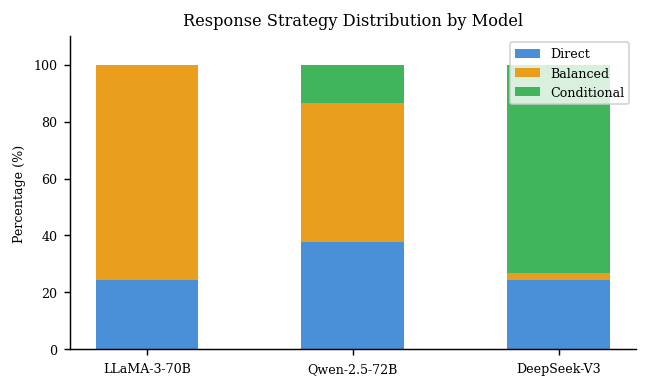

In [5]:
data = {}
for model in models:
    subset = df[df["model"] == model]["strategy"].value_counts(normalize=True) * 100
    data[model] = [subset.get(s, 0) for s in strategies]

fig, ax = plt.subplots(figsize=(5, 3))
bottom = [0] * len(models)
for strategy in strategies:
    values = [data[m][strategies.index(strategy)] for m in models]
    ax.bar(range(len(models)), values, bottom=bottom,
           color=STRATEGY_COLORS[strategy], label=strategy.capitalize(), width=0.5)
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_xticks(range(len(models)))
ax.set_xticklabels([MODEL_LABELS[m] for m in models])
ax.set_ylabel("Percentage (%)")
ax.set_title("Response Strategy Distribution by Model")
ax.legend(loc="upper right")
ax.set_ylim(0, 110)
sns.despine()
plt.tight_layout()
plt.show()


#### Key finding: 

DeepSeek favours conditional (~68%) 

LLaMA-3 balanced (~75%)

Qwen shows a mixed profile (~49% balanced, ~38% direct)

→ No model uses refusals.

---
## Figure 2: Hedging Language Score by Model


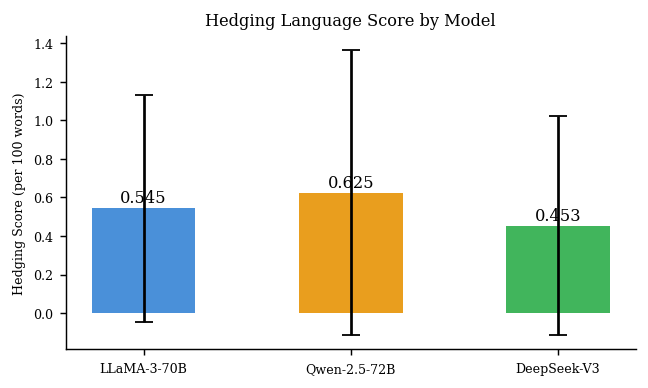

In [8]:
means = [df[df["model"]==m]["hedging_score"].mean() for m in models]
stds  = [df[df["model"]==m]["hedging_score"].std()  for m in models]

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar([MODEL_LABELS[m] for m in models], means, yerr=stds, capsize=5,
              color=[COLORS[m] for m in models], width=0.5,
              error_kw={"elinewidth": 1.5})
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{mean:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Hedging Score (per 100 words)")
ax.set_title("Hedging Language Score by Model")
sns.despine()
plt.tight_layout()
plt.show()


Qwen hedges most (0.625), DeepSeek least (0.453).

Difference is NOT statistically significant (p=0.391).

---
## Figure 3: Moral Language Score by Domain and Model


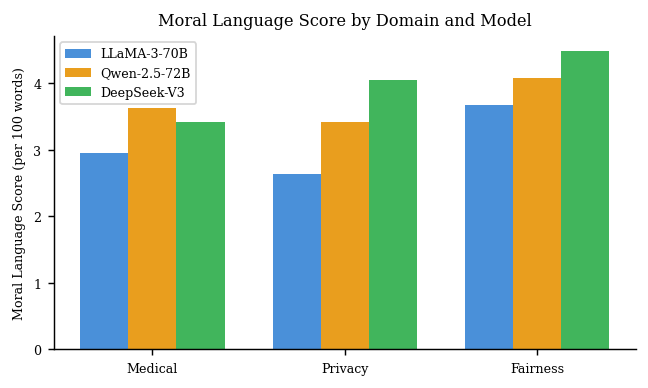

In [11]:
x, width = range(len(domains)), 0.25
fig, ax = plt.subplots(figsize=(5, 3))
for i, model in enumerate(models):
    means = [df[(df["model"]==model)&(df["domain"]==d)]["moral_score"].mean() for d in domains]
    ax.bar([xi + i*width for xi in x], means, width=width,
           color=COLORS[model], label=MODEL_LABELS[model])
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(["Medical", "Privacy", "Fairness"])
ax.set_ylabel("Moral Language Score (per 100 words)")
ax.set_title("Moral Language Score by Domain and Model")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


Fairness consistently elicits the most moral vocabulary across all models.
    
DeepSeek leads in all three domains.

---
## Figure 4: Sentiment Distribution by Model


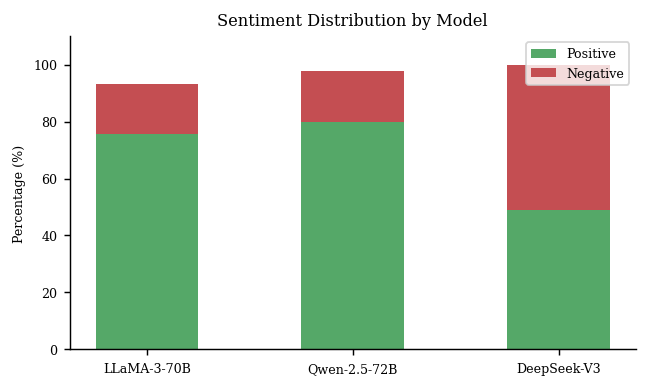

  LLaMA-3-70B: mean VADER = 0.451
  Qwen-2.5-72B: mean VADER = 0.527
  DeepSeek-V3: mean VADER = -0.041


In [14]:
sentiments = ["positive", "negative"]
sent_colors = {"positive": "#55A868", "negative": "#C44E52"}

data = {}
for model in models:
    subset = df[df["model"]==model]["sentiment_label"].value_counts(normalize=True) * 100
    data[model] = [subset.get(s, 0) for s in sentiments]

fig, ax = plt.subplots(figsize=(5, 3))
bottom = [0] * len(models)
for sentiment in sentiments:
    values = [data[m][sentiments.index(sentiment)] for m in models]
    ax.bar(range(len(models)), values, bottom=bottom,
           color=sent_colors[sentiment], label=sentiment.capitalize(), width=0.5)
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_xticks(range(len(models)))
ax.set_xticklabels([MODEL_LABELS[m] for m in models])
ax.set_ylabel("Percentage (%)")
ax.set_title("Sentiment Distribution by Model")
ax.legend(loc="upper right")
ax.set_ylim(0, 110)
sns.despine()
plt.tight_layout()
plt.show()

for m in models:
    mean_s = df[df["model"]==m]["sentiment_compound"].mean()
    print(f"  {MODEL_LABELS[m]}: mean VADER = {mean_s:.3f}")


---
## Figure 5: Response Length Distribution by Model


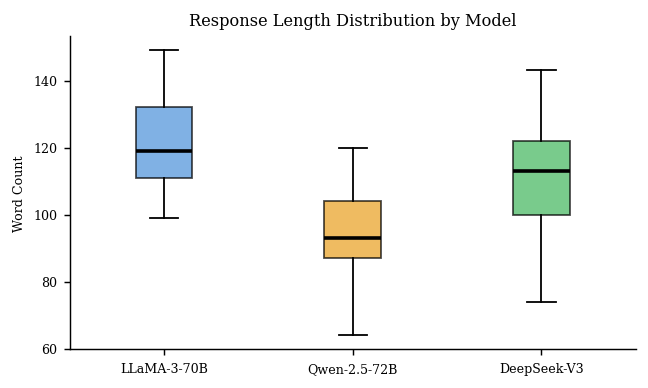

Median word counts:
  LLaMA-3-70B: 119 words
  Qwen-2.5-72B: 93 words
  DeepSeek-V3: 113 words


In [16]:
data_len = [df[df["model"]==m]["response_length"].values for m in models]

fig, ax = plt.subplots(figsize=(5, 3))
bp = ax.boxplot(data_len, patch_artist=True,
                medianprops={"color": "black", "linewidth": 2})
for patch, model in zip(bp["boxes"], models):
    patch.set_facecolor(COLORS[model])
    patch.set_alpha(0.7)
ax.set_xticklabels([MODEL_LABELS[m] for m in models])
ax.set_ylabel("Word Count")
ax.set_title("Response Length Distribution by Model")
sns.despine()
plt.tight_layout()
plt.show()

print("Median word counts:")
for m, d in zip(models, data_len):
    print(f"  {MODEL_LABELS[m]}: {np.median(d):.0f} words")


---
## Figure 6: Certainty Score by Domain and Model


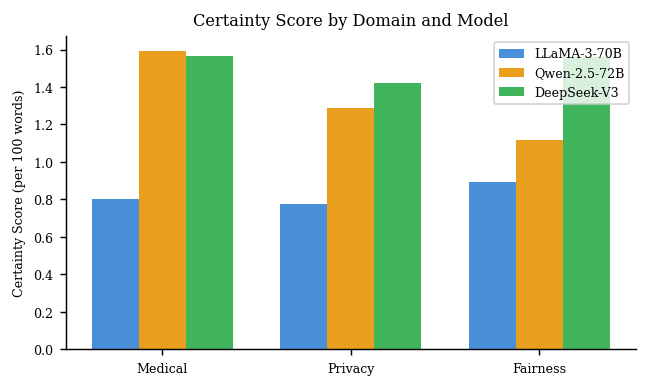

In [18]:
fig, ax = plt.subplots(figsize=(5, 3))
for i, model in enumerate(models):
    means = [df[(df["model"]==model)&(df["domain"]==d)]["certainty_score"].mean() for d in domains]
    ax.bar([xi + i*width for xi in x], means, width=width,
           color=COLORS[model], label=MODEL_LABELS[model])
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(["Medical", "Privacy", "Fairness"])
ax.set_ylabel("Certainty Score (per 100 words)")
ax.set_title("Certainty Score by Domain and Model")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


LLaMA-3 consistently scores lowest on certainty across all domains.

Medical ethics elicits the most assertive language.


---
## Statistical Tests: Kruskal-Wallis Results

Before showing the benchmark results, here is a summary of the
statistical significance of inter-model differences.


In [21]:
test_metrics = {
    "hedging_score":   "Hedging Score",
    "moral_score":     "Moral Language",
    "certainty_score": "Certainty Score",
    "response_length": "Response Length",
}

print(f"{'Metric':<22} {'H-stat':>8} {'p-value':>10} {'Significant':>14}")
print("-" * 58)
for col, label in test_metrics.items():
    groups = [df[df["model"]==m][col].values for m in models]
    h, p = stats.kruskal(*groups)
    sig = "Yes ✓" if p < 0.05 else "No  ✗"
    print(f"{label:<22} {h:>8.3f} {p:>10.4f} {sig:>14}")


Metric                   H-stat    p-value    Significant
----------------------------------------------------------
Hedging Score             1.878     0.3910          No  ✗
Moral Language            6.169     0.0458          Yes ✓
Certainty Score          19.628     0.0001          Yes ✓
Response Length          58.687     0.0000          Yes ✓


---
## Figures 9 & 10: SHAP Explainability

These charts were generated in `03_classification_and_shap.ipynb`.
They are loaded here for the complete results presentation.


Figure 9 — Global Feature Importance (SHAP)


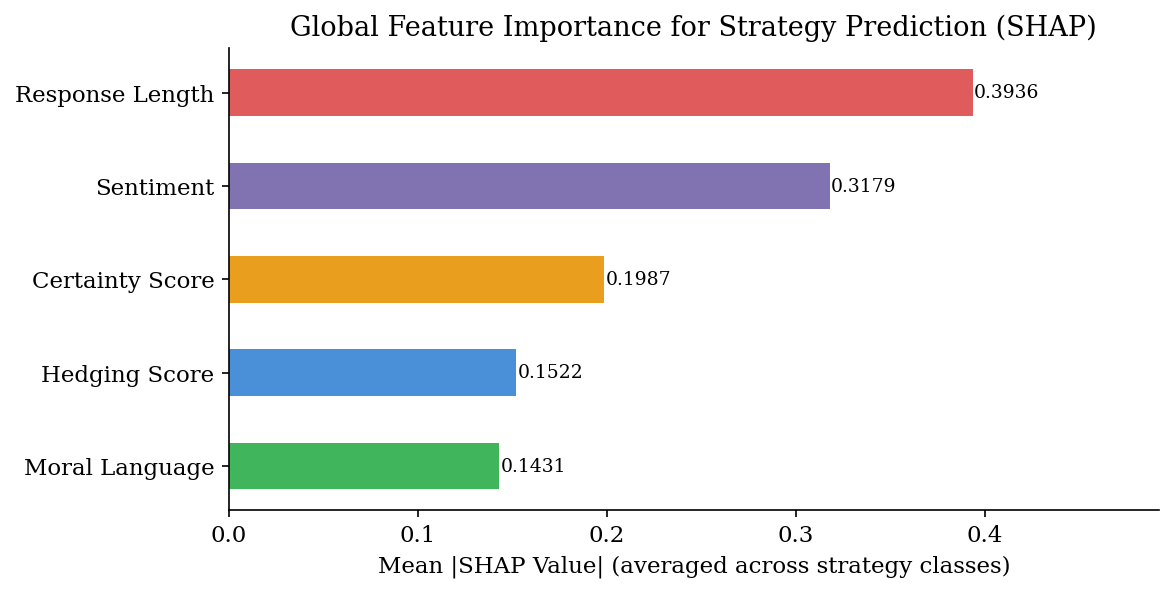

In [23]:
print("Figure 9 — Global Feature Importance (SHAP)")
display(Image("results/charts/09_shap_bar.png", width=600))


Figure 10 — Per-Class SHAP Beeswarm


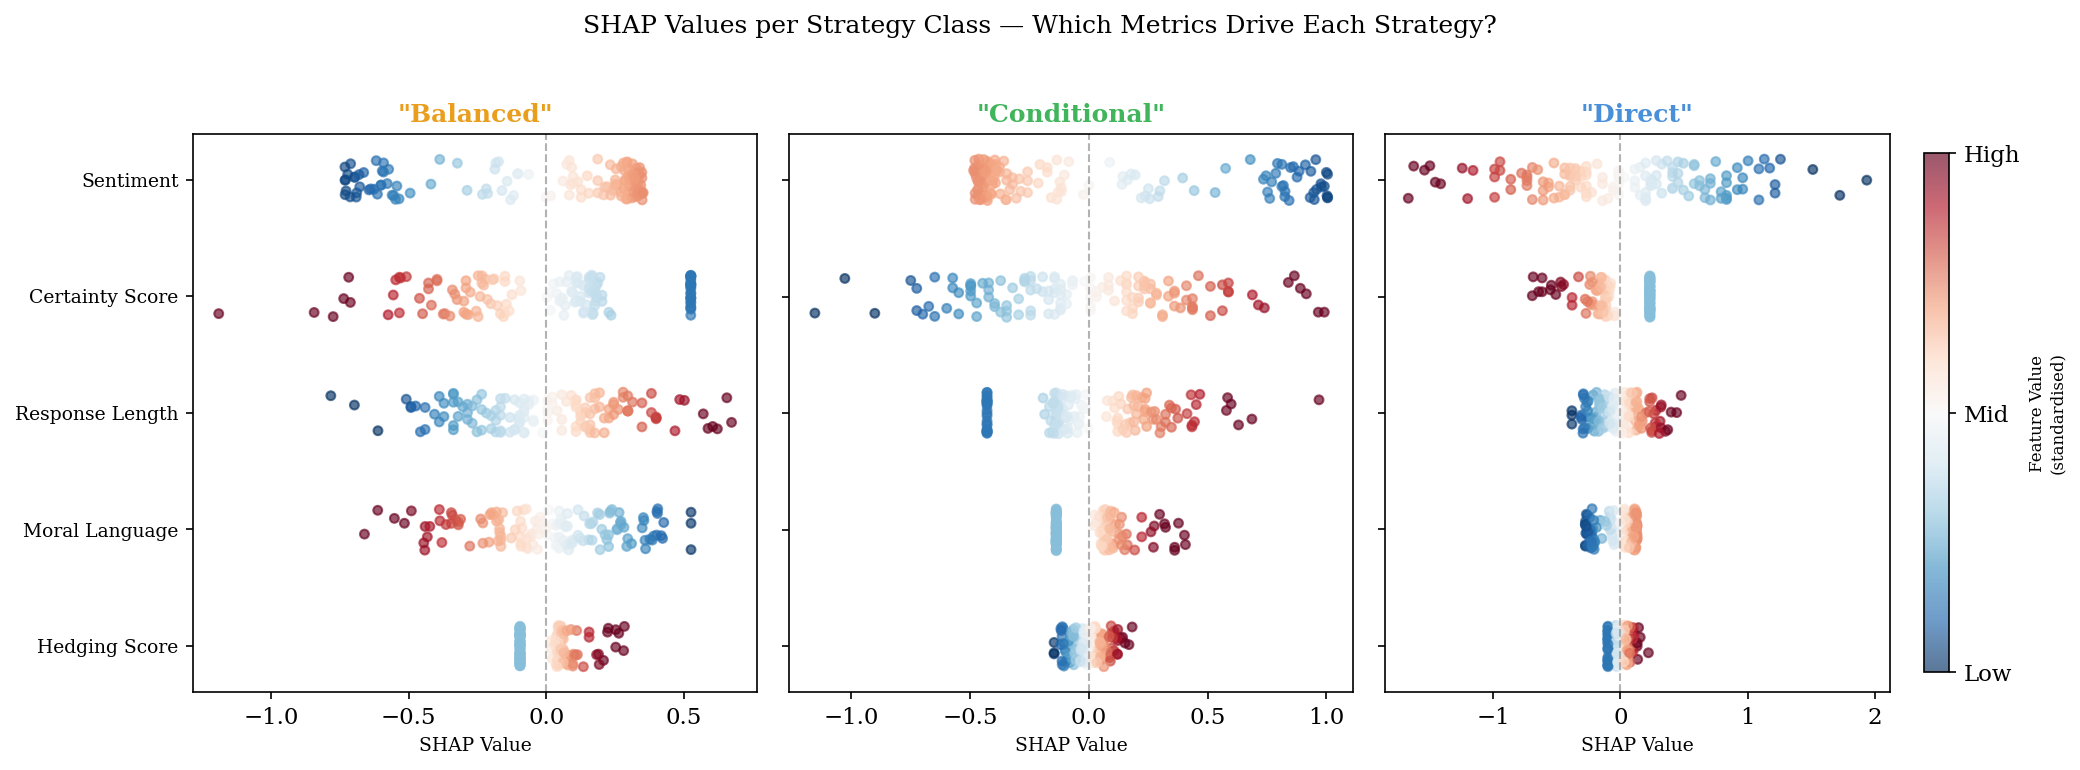

In [24]:
print("Figure 10 — Per-Class SHAP Beeswarm")
display(Image("results/charts/10_shap_beeswarm.png", width=800))


---
## Figure 8: ETHICS Benchmark: Moral Alignment Accuracy


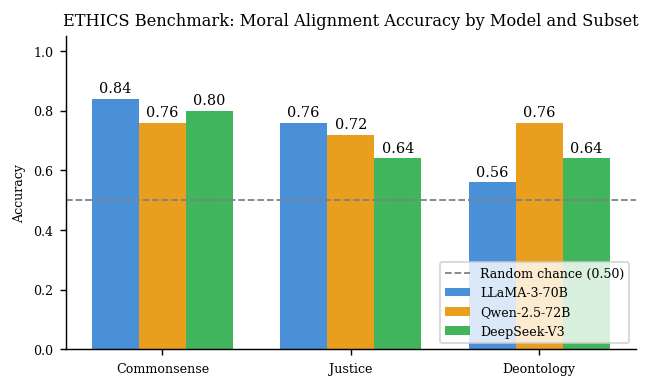

In [26]:
subsets      = ["commonsense", "justice", "deontology"]
subset_labels = ["Commonsense", "Justice", "Deontology"]
x = range(len(subsets))
width = 0.25

fig, ax = plt.subplots(figsize=(5, 3))
for i, model in enumerate(models):
    accs = []
    for subset in subsets:
        row = df_ethics[(df_ethics["model"]==model) & (df_ethics["subset"]==subset)]
        accs.append(float(row["accuracy"].values[0]) if len(row) > 0 else 0.0)
    bars = ax.bar([xi + i*width for xi in x], accs, width=width,
                  color=COLORS[model], label=MODEL_LABELS[model])
    for bar, acc in zip(bars, accs):
        if acc > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{acc:.2f}", ha="center", va="bottom", fontsize=8)

ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=1, label="Random chance (0.50)")
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(subset_labels)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("ETHICS Benchmark: Moral Alignment Accuracy by Model and Subset")
ax.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()


In [27]:
# Summary table
pivot = df_ethics.pivot_table(index="model", columns="subset",
                               values="accuracy").round(3)
pivot.index = [MODEL_LABELS[m] for m in pivot.index]
pivot.columns = [c.capitalize() for c in pivot.columns]
print("ETHICS Benchmark Accuracy:")
print(pivot.to_string())
print()
print(f"Qwen range  : {pivot.loc['Qwen-2.5-72B'].max() - pivot.loc['Qwen-2.5-72B'].min():.3f}  (most consistent)")
print(f"LLaMA range : {pivot.loc['LLaMA-3-70B'].max() - pivot.loc['LLaMA-3-70B'].min():.3f}  (highest variance)")


ETHICS Benchmark Accuracy:
              Commonsense  Deontology  Justice
DeepSeek-V3          0.80        0.64     0.64
LLaMA-3-70B          0.84        0.56     0.76
Qwen-2.5-72B         0.76        0.76     0.72

Qwen range  : 0.040  (most consistent)
LLaMA range : 0.280  (highest variance)


---
## Comprehensive Results Discussion

### Three distinct model profiles


In [51]:
print("=" * 65)
print("MODEL PROFILES SUMMARY")
print("=" * 65)

profiles = {
    "LLaMA-3-70B": {
        "strategy":    "Predominantly BALANCED (~75%)",
        "length":      "Longest responses (~120 words median)",
        "hedging":     "Moderate hedging (0.545)",
        "certainty":   "LOWEST certainty (0.823)",
        "moral":       "Lowest moral vocabulary (3.090)",
        "sentiment":   "Positive (mean: 0.451)",
        "ethics_best": "Commonsense (0.84)",
        "ethics_worst":"Deontology (0.56 — near random)",
        "profile":     "Verbose, non-committal, acknowledges complexity without resolving",
    },
    "Qwen-2.5-72B": {
        "strategy":    "Mixed profile (~49% balanced, ~38% direct)",
        "length":      "Shortest responses (~93 words median)",
        "hedging":     "HIGHEST hedging (0.625)",
        "certainty":   "High certainty (1.334)",
        "moral":       "Moderate moral vocabulary (3.713)",
        "sentiment":   "Most positive (mean: 0.527)",
        "ethics_best": "Consistent across all subsets (0.72–0.76)",
        "ethics_worst":"Justice (0.72 — still moderate)",
       "profile":     "Concise, versatile mixed profile — balances hedging with pragmatic commitment",
    },
    "DeepSeek-V3": {
        "strategy":    "Predominantly CONDITIONAL (~68%)",
        "length":      "Medium responses (~112 words median)",
        "hedging":     "LOWEST hedging (0.453)",
        "certainty":   "HIGHEST certainty (1.516)",
        "moral":       "Most moral vocabulary (3.987)",
        "sentiment":   "Near-neutral (mean: -0.041)",
        "ethics_best": "Commonsense (0.80)",
        "ethics_worst":"Justice (0.64)",
        "profile":     "Morally expressive, assertive, near-neutral — engages with moral gravity",
    }
}

for model_name, p in profiles.items():
    print(f"\n[{model_name}]")
    print(f"  Strategy    : {p['strategy']}")
    print(f"  Length      : {p['length']}")
    print(f"  Hedging     : {p['hedging']}")
    print(f"  Certainty   : {p['certainty']}")
    print(f"  Moral vocab : {p['moral']}")
    print(f"  Sentiment   : {p['sentiment']}")
    print(f"  ETHICS best : {p['ethics_best']}")
    print(f"  ETHICS worst: {p['ethics_worst']}")
    print(f"  → Profile   : {p['profile']}")


MODEL PROFILES SUMMARY

[LLaMA-3-70B]
  Strategy    : Predominantly BALANCED (~75%)
  Length      : Longest responses (~120 words median)
  Hedging     : Moderate hedging (0.545)
  Certainty   : LOWEST certainty (0.823)
  Moral vocab : Lowest moral vocabulary (3.090)
  Sentiment   : Positive (mean: 0.451)
  ETHICS best : Commonsense (0.84)
  ETHICS worst: Deontology (0.56 — near random)
  → Profile   : Verbose, non-committal, acknowledges complexity without resolving

[Qwen-2.5-72B]
  Strategy    : Mixed profile (~49% balanced, ~38% direct)
  Length      : Shortest responses (~93 words median)
  Hedging     : HIGHEST hedging (0.625)
  Certainty   : High certainty (1.334)
  Moral vocab : Moderate moral vocabulary (3.713)
  Sentiment   : Most positive (mean: 0.527)
  ETHICS best : Consistent across all subsets (0.72–0.76)
  ETHICS worst: Justice (0.72 — still moderate)
  → Profile   : Concise, versatile mixed profile — balances hedging with pragmatic commitment

[DeepSeek-V3]
  Strategy 

### Key cross-cutting findings

### Findings
    1. Zero refusals: All 3 models engaged with every sensitive scenario. No model deflected or refused.
        Instruction-tuned models at 70B+ scale have moved beyond surface-level filtering.

    2. Open-ended reasoning ≠ binary alignment: LLaMA-3 produces the richest balanced responses but nearly fails deontological
       classification (0.56). Strong open-ended moral reasoning and binary moral alignment are empirically DISTINCT capabilities.
       
    3. The epistemic paradox (Qwen): Qwen hedges most (0.625) yet is highly certain (1.334).
       This reflects a pragmatic pattern: acknowledge uncertainty, then commit.
       LLaMA-3 hedges without committing — balanced to a fault.
       Qwen shows the most versatile strategy profile (~49% balanced, ~38% direct).
       
    4. Deontology is hardest: All models struggle with deontological reasoning.
       Evaluating whether an excuse justifies an action requires rule-based inference that current models handle inconsistently.
       
    5. SHAP: sentiment and length drive strategy: Response length is the strongest global predictor of rhetorical strategy.
       Low sentiment → direct. Long + high sentiment + high hedging + low certainty → balanced.
       Conditional is driven by high certainty + high moral language + high hedging + low sentiment: the most structurally complex strategy of the three.
       
    6. Fairness elicits most moral vocabulary: Fairness scenarios consistently activate more ethical framing than medical
       or privacy scenarios across all three models.


---
## Project Summary

| Component | Details |
|---|---|
| **Custom dataset** | 45 scenarios × 3 models = 135 open-ended responses |
| **Domains** | Medical, Privacy, Fairness (15 scenarios each) |
| **Models** | LLaMA-3-70B, Qwen-2.5-72B, DeepSeek-V3 |
| **Metrics** | 6 linguistic metrics + VADER sentiment |
| **Classification** | BERT + SVM strategy classifier (direct/balanced/conditional) |
| **Explainability** | SHAP on logistic regression (5 linguistic features) |
| **Benchmark** | ETHICS dataset : 75 scenarios × 3 models = 225 binary classifications |
| **Statistical tests** | Kruskal-Wallis (certainty, moral, length: significant; hedging: not) |
| **Charts produced** | 10 figures |

### Pipeline
```
collect.py → responses.json
    ↓
analyze.py → metrics.csv
    ↓
classify_svm.py → strategy labels in metrics.csv
    ↓
shap_analysis.py → SHAP charts
    ↓
sample_ethics.py → ethics_sample.json
    ↓
ethics_eval.py → ethics_results.csv + ethics_summary.csv
    ↓
visualize.py → 10 charts
```
